# IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ghibtools as gh
import pingouin as pg
from scipy.stats import spearmanr, median_abs_deviation
import os

from configuration import *
from dataio import *
from utils import radar_factory, concatenate_psycho, get_mental_activities, plot_correlation_matrix
from analyse_memory import *
from anova_permutation import anova_permutation
from modular_eeg_preprocess import compute_modular_eeg_proprocessing_all
from analyses_eeg import compute_spectrum_all, plot_correlation_EEG_memory

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "4" redefined by R and overriding existing variable. Current: "C:\ProgramData", R: ""1""
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "5" redefined by R and overriding existing variable. Current: "C:\Users\marion.walter\AppData\Roaming", R: "C:\Program Files\Common Files"
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "7" redefined by R and overriding existing variable. Current: "\\.\pipe\crashpad_22348_PQEUXEVRBNLXQRKX", R: "\\.\pipe\22e31b28-1.126.0-main-sock"
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\r

# CODE

## Article section 3.1	No beneficial effect of rest on memory performances

### Global Memory Change (GMC)

GMC = ((score at final recall - score at initial recall)/(score at initial recall))*100).

### get dataframe

In [ ]:
df = get_all_trials_data_with_trial_numbers()
df_GMC = compute_global_memory_change(df)
df_GMC

phase == 'E1'
phase == 'E2'
phase == 'R1'
phase == 'R2'
phase == 'RF'


,subject,condition,GMC,order
0,sub-01,Distraction,6.250000,D-R
1,sub-01,Rest,4.545455,D-R
2,sub-07,Rest,-6.250000,R-D
3,sub-07,Distraction,4.761905,R-D
4,sub-10,Distraction,-21.428571,D-R
5,sub-10,Rest,9.090909,D-R
6,sub-12,Rest,-9.090909,R-D
7,sub-12,Distraction,-5.000000,R-D
8,sub-14,Rest,6.666667,R-D
9,sub-14,Distraction,0.000000,R-D


### Figure 2A

          W_val alternative     p_val       RBC      CLES
Wilcoxon  134.0   two-sided  0.451132 -0.175385  0.461111
{'p': np.float64(0.4511315345126442), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


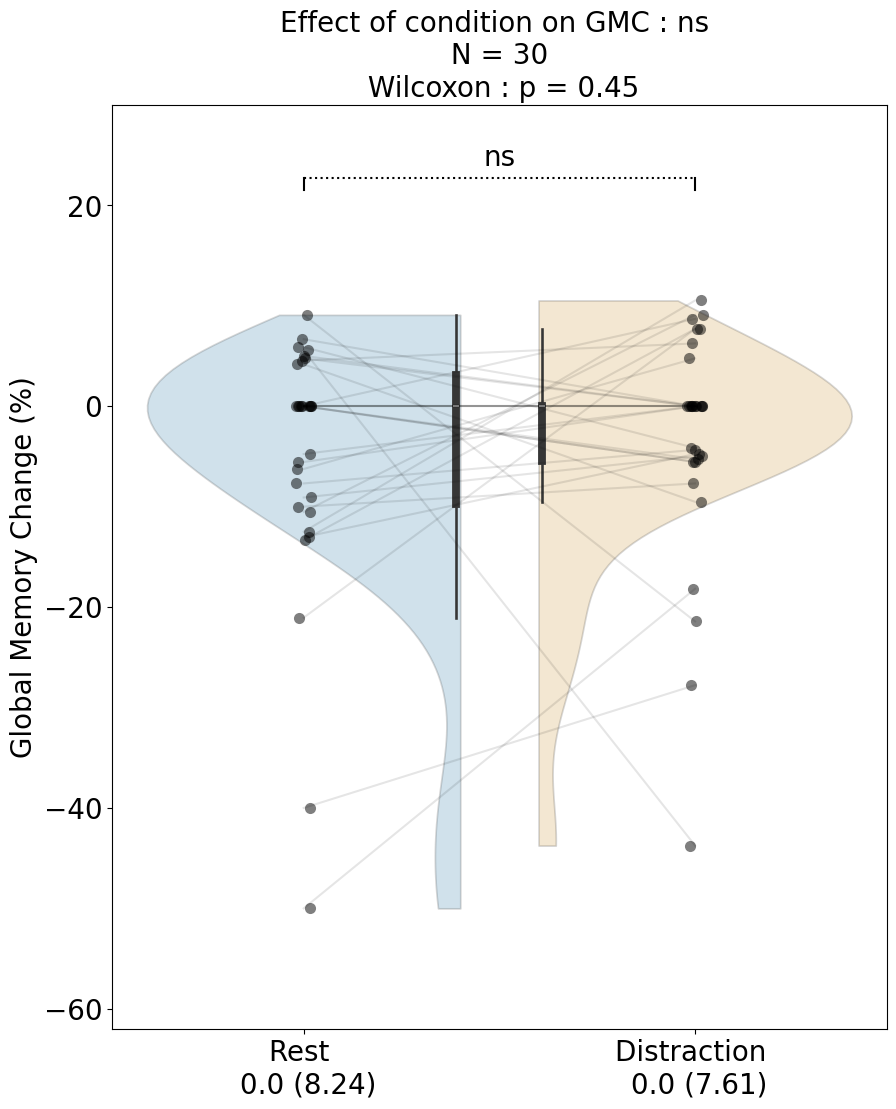

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(df_GMC, 
              outcome='GMC', 
              design='within',
              subject='subject',
              palette=palette,
              predictor='condition',
              order=order,
              return_pval=True,
              fontsize=20,
              ax=ax)

ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel('')
ax.set_ylabel('Global Memory Change (%)', fontsize=20)
ax.set_ylim(-62, 30)
ax.tick_params(axis='x', labelsize=20)

# fig.savefig(os.path.join(figures_path, 'Figure_2A.png'), dpi=300, format='png', bbox_inches='tight')
fig.savefig(os.path.join(figures_path, 'Figure_2A.pdf'), format='pdf', bbox_inches='tight')

For statistics, I used a homemade toolbox made by Valentin Ghibaudo called 'ghibtools', available here : https://github.com/ValentinGhibaudo/ghibtools and slightly customed by me for vizualisation purposes.

This toolbox allows to perform statistical tests and display the results automatically using the pingouin library. For those who would like a quick check, here are the results of the Wilcoxon test calculated using ghibtools, and those calculated directly 

In [ ]:
rest_data = df_GMC[df_GMC['condition'] == 'Rest']['GMC']
distraction_data = df_GMC[df_GMC['condition'] == 'Distraction']['GMC']

inferential_stats = pg.wilcoxon(rest_data, distraction_data, alternative='two-sided')
print(inferential_stats)

print('##########################################')

res = gh.auto_stats_summary(df_GMC, predictor='condition', outcome='GMC', design='within', subject='subject')
print(res)

          W_val alternative     p_val       RBC      CLES
Wilcoxon  134.0   two-sided  0.451132 -0.175385  0.461111
##########################################
          W_val alternative     p_val       RBC      CLES
Wilcoxon  134.0   two-sided  0.451132 -0.175385  0.461111
{'descriptive_stats':               N      mean         sd       sem median       mad  \
Distraction  30 -3.609852  11.532393  2.105517    0.0  7.608079   
Rest         30 -5.271231  13.048018  2.382231    0.0  8.236667   

                       CI95  
Distraction    [-7.92, 0.7]  
Rest         [-10.14, -0.4]  , 'inferential_stats':           W_val alternative     p_val       RBC      CLES ES interpretation
Wilcoxon  134.0   two-sided  0.451132 -0.175385  0.461111                 S}


## Article section 3.2	No relationship between EEG activity and memory performances

### Preprocess EEG

In [3]:
compute_modular_eeg_proprocessing_all()

modular_eeg_preprocessing already processed ('sub-01_Repos',)
modular_eeg_preprocessing already processed ('sub-01_Distraction',)
modular_eeg_preprocessing already processed ('sub-10_Repos',)
modular_eeg_preprocessing already processed ('sub-10_Distraction',)
modular_eeg_preprocessing already processed ('sub-20_Repos',)
modular_eeg_preprocessing already processed ('sub-20_Distraction',)
modular_eeg_preprocessing already processed ('sub-22_Repos',)
modular_eeg_preprocessing already processed ('sub-22_Distraction',)
modular_eeg_preprocessing already processed ('sub-24_Repos',)
modular_eeg_preprocessing already processed ('sub-24_Distraction',)
modular_eeg_preprocessing already processed ('sub-30_Repos',)
modular_eeg_preprocessing already processed ('sub-30_Distraction',)
modular_eeg_preprocessing already processed ('sub-38_Repos',)
modular_eeg_preprocessing already processed ('sub-38_Distraction',)
modular_eeg_preprocessing already processed ('sub-40_Repos',)
modular_eeg_preprocessing al

### Compute spectrum analysis

Run this function to compute spectrum analysis for all subject and conditions

In [2]:
compute_spectrum_all()

compute_spectrum_replication_inspired is processing ('sub-01_Repos',)
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Computing spectrum with replication-inspired parameters on 4-second window.
Effective window size : 4.000 (s)
PSD computed with 4.0 s window and 50% overlap
compute_spectrum_replication_inspired is processing ('sub-01_Distraction',)
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Computing spectrum with replication-inspired parameters on 4-second window.
Effective window size : 4.000 (s)
PSD computed with 4.0 s window and 50% overlap
compute_spectrum_replication_inspired is processing ('sub-10_Repos',)
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Computing spectrum with replication-inspired parameters on 4-second window.
Effective window size : 4.000 (s)
PSD computed with 4.0 s window and 50% overlap
compute_spectrum_replication_inspired is processing ('sub-10_Dis

### Plot correlations

#### Replication-inspired analysis - ranked data (Figure 3A and 4A)

Note : this function also generates the correlations for the Distraction condition. These data and figures are not used in the article. Figures for Distraction condition are stored in a different folder.


--- Starting Replication-Inspired Analysis ---
rank_data: True
Using replication-inspired GMC memory performance computation.
phase == 'E1'
phase == 'E2'
phase == 'R1'
phase == 'R2'
phase == 'RF'
Processing order: both
Processing band: Slow (0.3 - 1 Hz)
Using replication-inspired params for correlation analysis.

--- Generating figure ---
Condition: Rest
Frequency Band: Slow (0.3 - 1 Hz)
Replication Inspired: True
Rank Data: True
Figure Name: Figure_3A.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures
------------------------



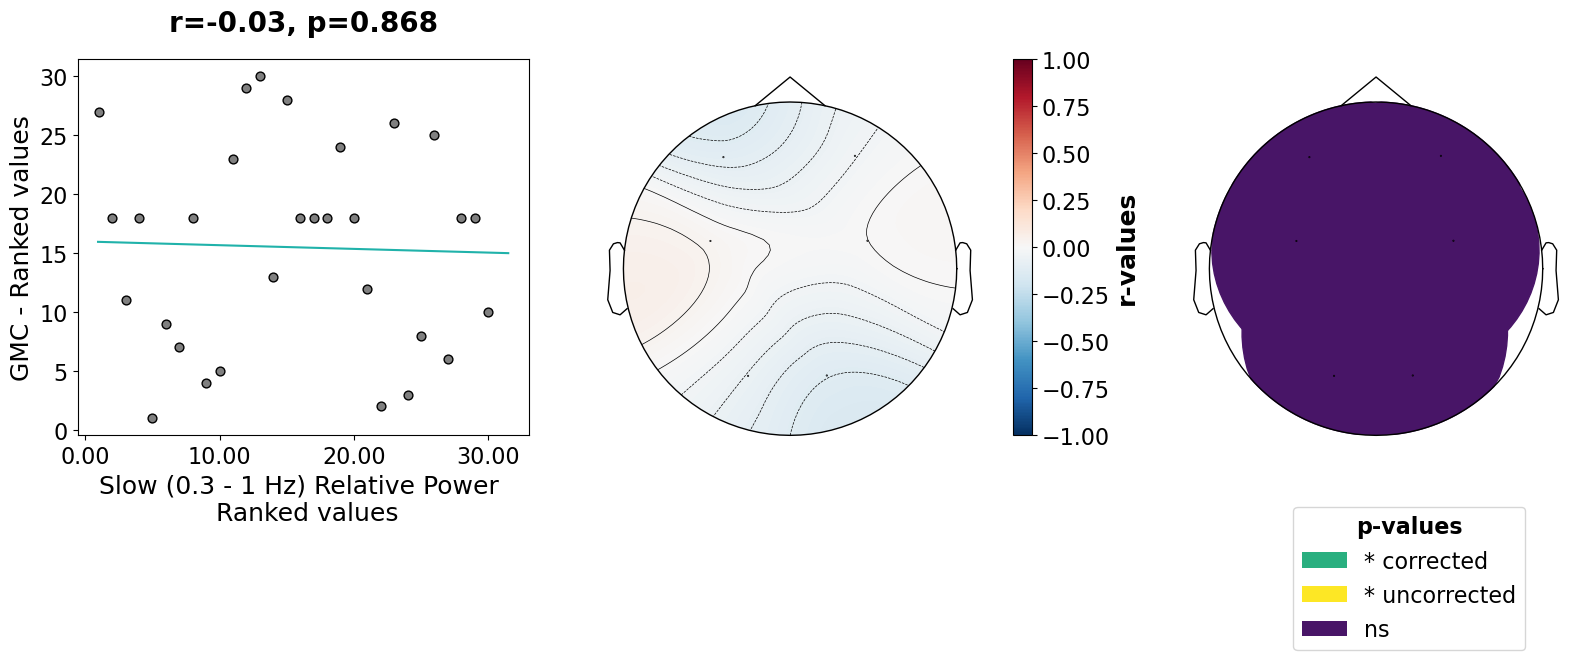

Processing band: Alpha (8 - 12 Hz)
Using replication-inspired params for correlation analysis.

--- Generating figure ---
Condition: Rest
Frequency Band: Alpha (8 - 12 Hz)
Replication Inspired: True
Rank Data: True
Figure Name: Figure_4A.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures
------------------------



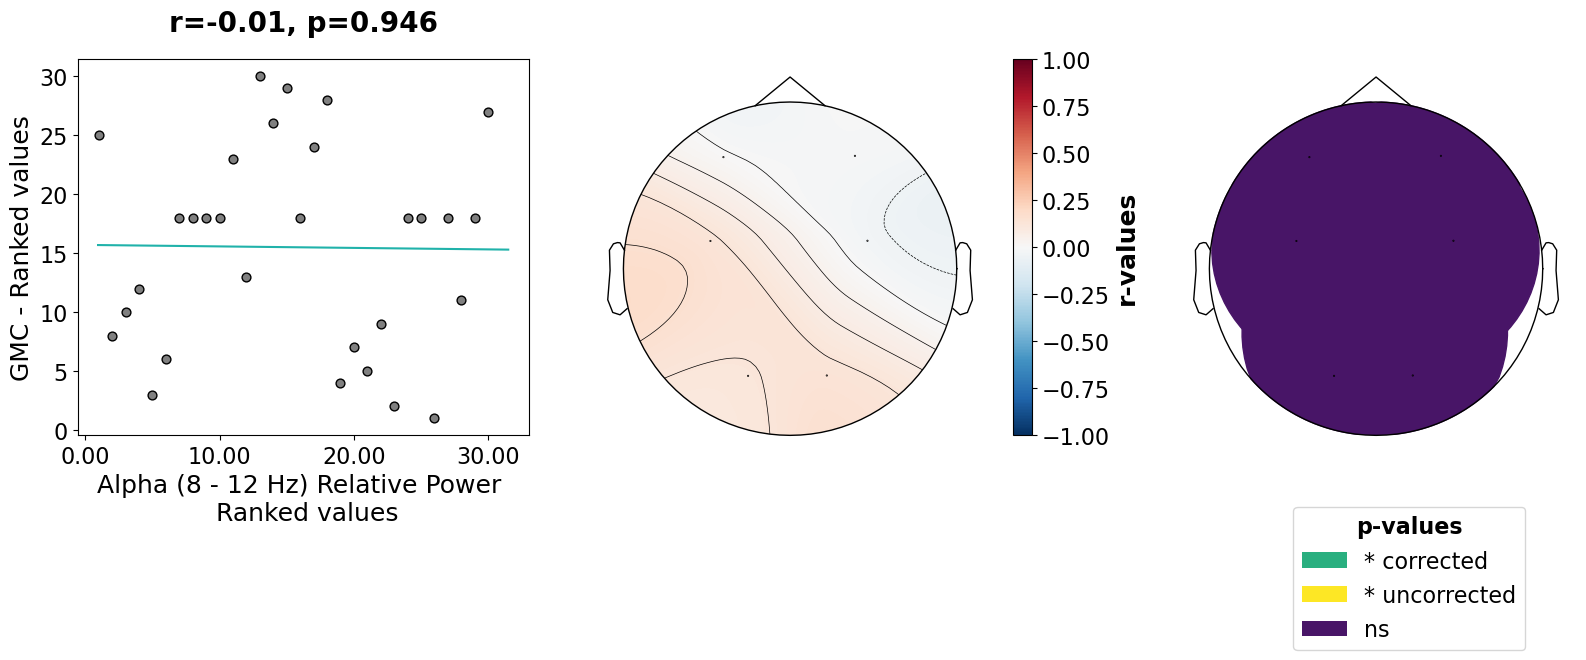

Processing order: both
Processing band: Slow (0.3 - 1 Hz)
Using replication-inspired params for correlation analysis.

--- Generating figure ---
Condition: Distraction
Frequency Band: Slow (0.3 - 1 Hz)
Replication Inspired: True
Rank Data: True
Figure Name: Order-both_Slow (0.3 - 1 Hz)_Cond-Distraction_ranked.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures\unused_figures
------------------------



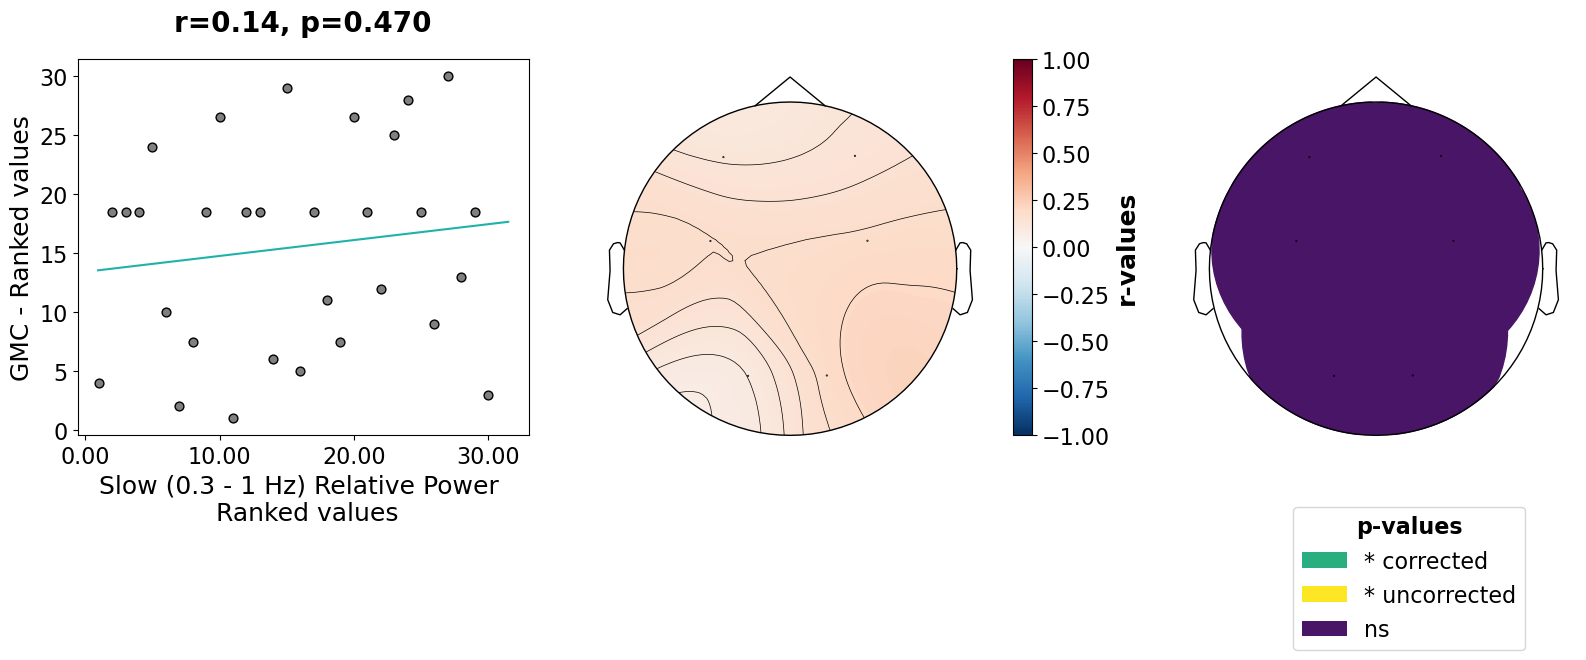

Processing band: Alpha (8 - 12 Hz)
Using replication-inspired params for correlation analysis.

--- Generating figure ---
Condition: Distraction
Frequency Band: Alpha (8 - 12 Hz)
Replication Inspired: True
Rank Data: True
Figure Name: Order-both_Alpha (8 - 12 Hz)_Cond-Distraction_ranked.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures\unused_figures
------------------------



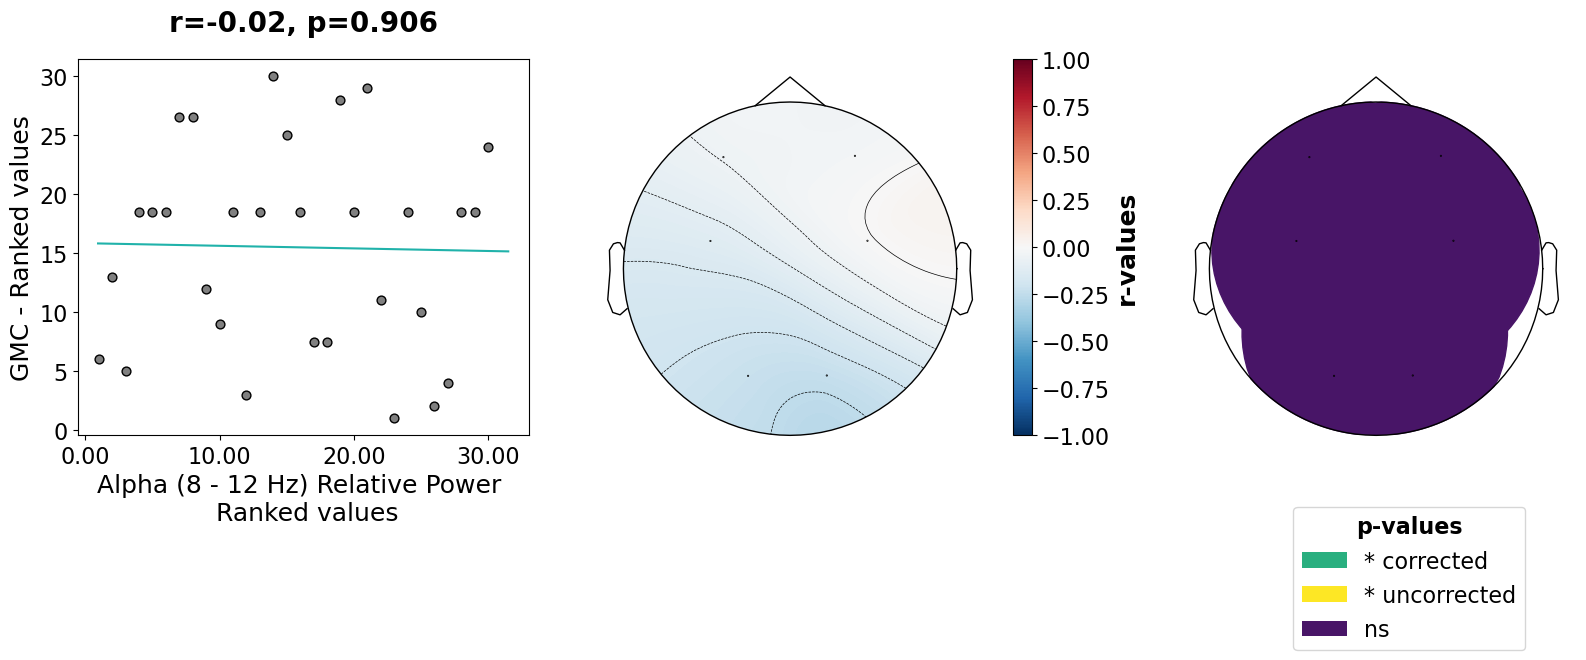

Figures for replication-inspired analysis (ranked data) computed


In [2]:
plot_correlation_EEG_memory(ranked_data=True, replication_inspired_analysis=True)

#### Data-adapted analysis - ranked data (Figure 3B and 4B)

Note : this function also generates the correlations for the Distraction condition. These data and figures are not used in the article. Figures for Distraction condition are stored in a different folder.


--- Starting Data-Adapted ---
rank_data: True
Using RMC memory performance computation.
Processing order: both
Processing band: Slow (0.3 - 1 Hz)
Using data-adapted params for correlation analysis.

--- Generating figure ---
Condition: Rest
Frequency Band: Slow (0.3 - 1 Hz)
Replication Inspired: False
Rank Data: True
Figure Name: Figure_3B.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures
------------------------



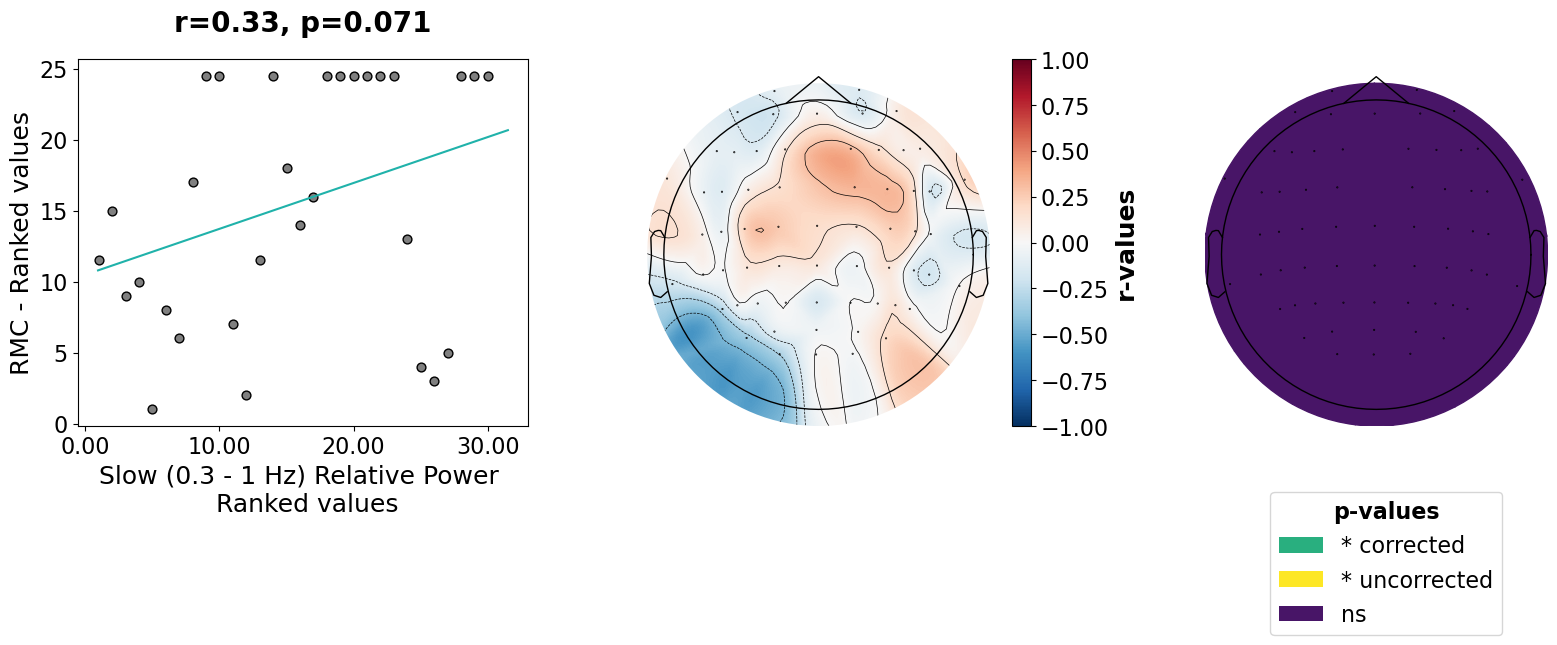

Processing band: Alpha (8 - 12 Hz)
Using data-adapted params for correlation analysis.

--- Generating figure ---
Condition: Rest
Frequency Band: Alpha (8 - 12 Hz)
Replication Inspired: False
Rank Data: True
Figure Name: Figure_4B.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures
------------------------



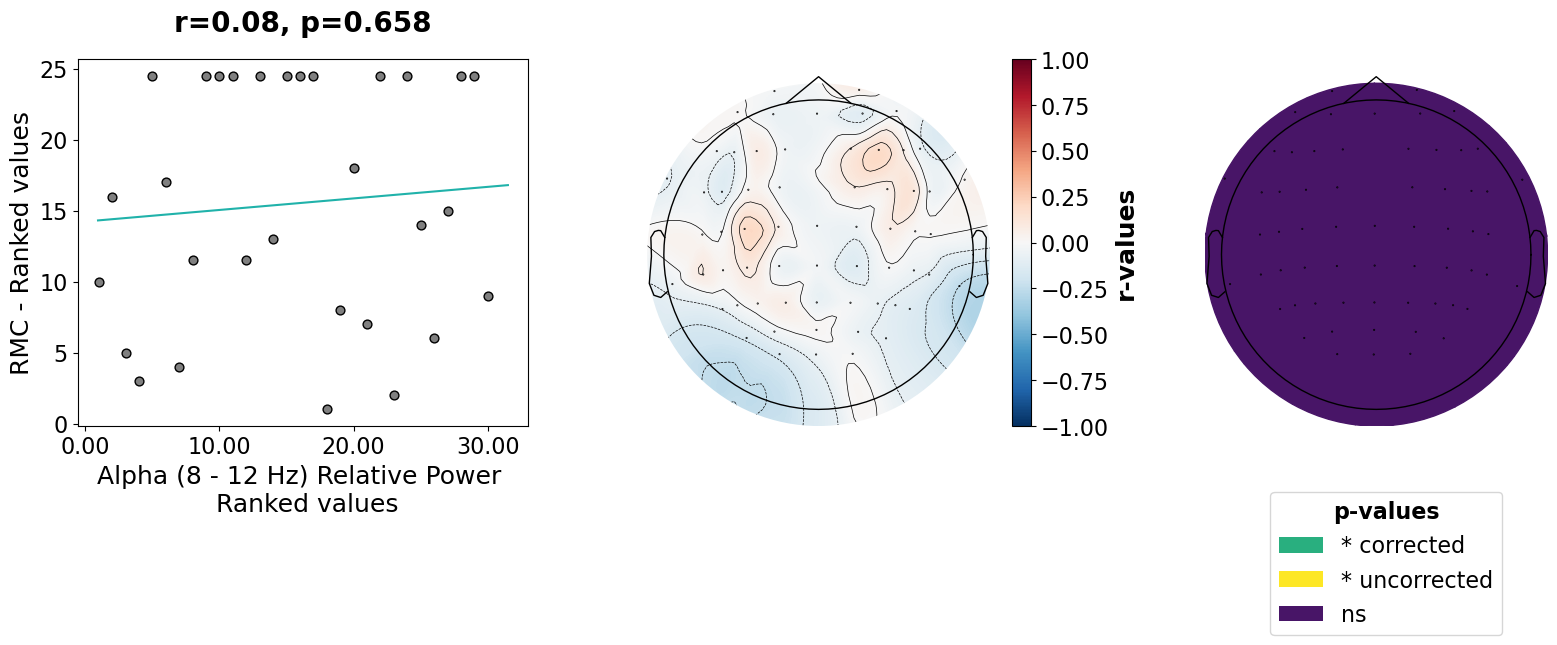

Processing order: both
Processing band: Slow (0.3 - 1 Hz)
Using data-adapted params for correlation analysis.

--- Generating figure ---
Condition: Distraction
Frequency Band: Slow (0.3 - 1 Hz)
Replication Inspired: False
Rank Data: True
Figure Name: Order-both_Slow (0.3 - 1 Hz)_Cond-Distraction_ranked.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures\unused_figures
------------------------



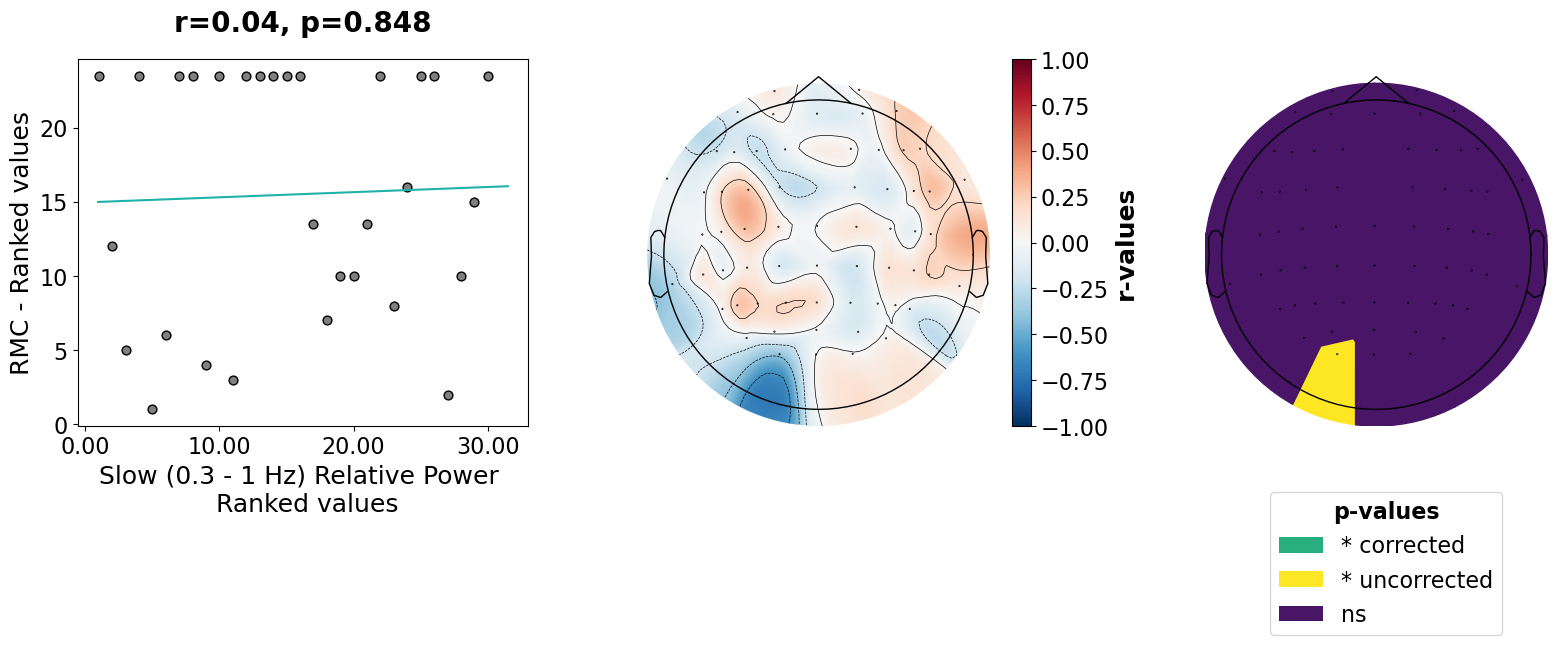

Processing band: Alpha (8 - 12 Hz)
Using data-adapted params for correlation analysis.

--- Generating figure ---
Condition: Distraction
Frequency Band: Alpha (8 - 12 Hz)
Replication Inspired: False
Rank Data: True
Figure Name: Order-both_Alpha (8 - 12 Hz)_Cond-Distraction_ranked.png
Folder: N:\cmo\Projets\RelaxCons_MW\NBuonviso202310_emosens_relax_cons_Marion\Article_PCJ\figures\unused_figures
------------------------



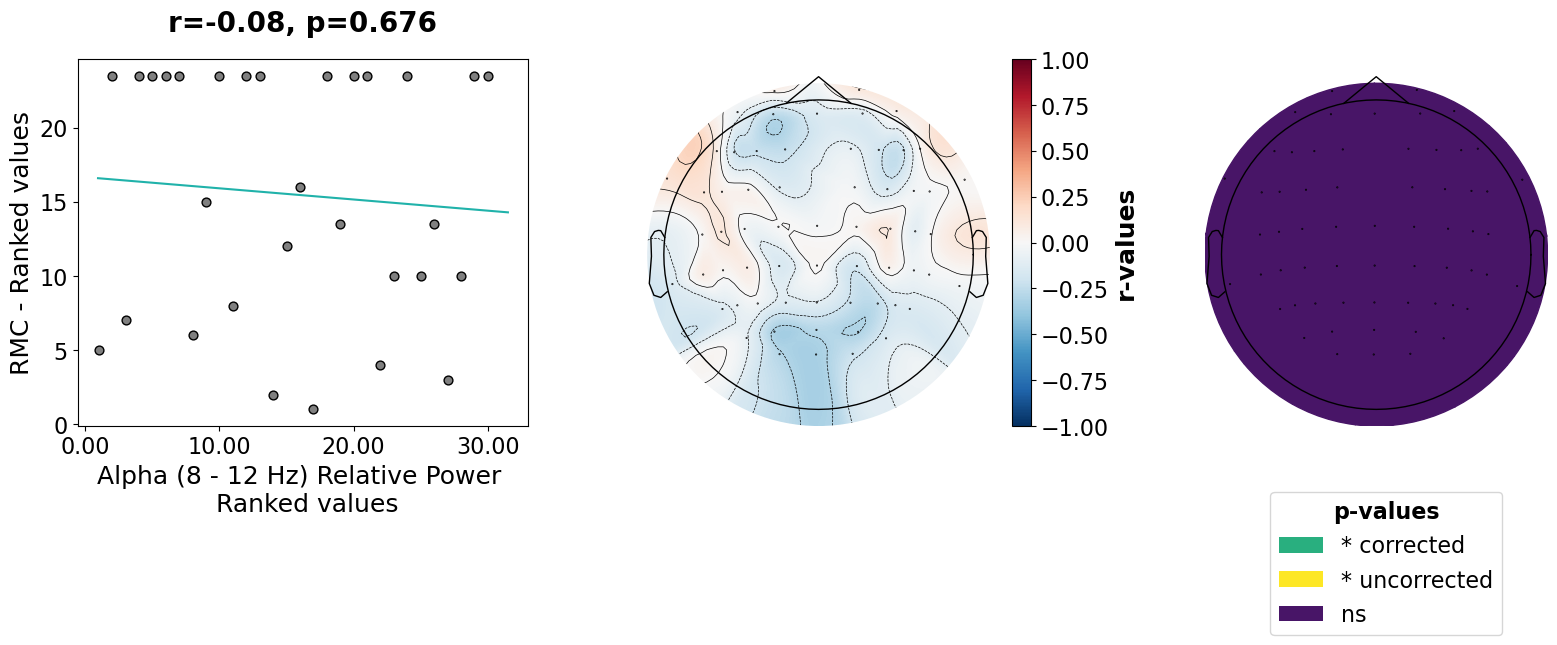

Figures for data-adapted analysis (ranked data) computed


In [3]:
plot_correlation_EEG_memory(ranked_data=True, replication_inspired_analysis=False)

## Article section 3.3	Relationship between memory performances, Daydreaming Frequency and mental activities

### DFS and Relative Memory Change

#### get dataframe

In [ ]:
df_RMC = compute_relative_memory_change()
meta_data = get_one_metadata_info('DFS_total')
df_corr = pd.merge (df_RMC, meta_data, on='subject')

#### Figure 5A

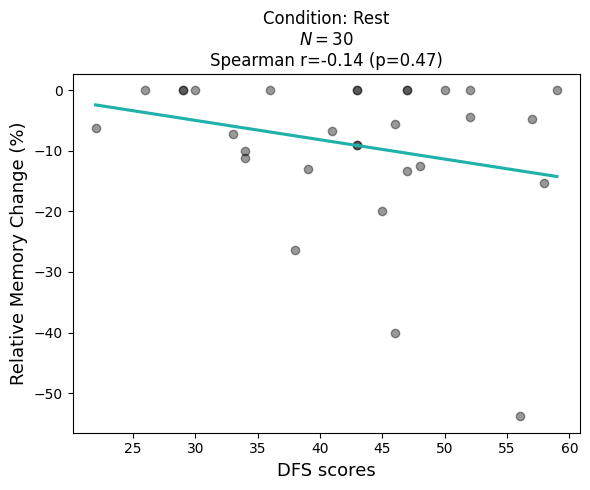

In [ ]:
x='DFS_total'
y='RMC'

sub_df = df_corr[df_corr['condition'] == 'Rest']

fig, ax = plt.subplots(figsize=(6, 5))

sns.regplot(data=sub_df, x=x, y=y, ax=ax, ci=None, scatter_kws={'color':'black','alpha': 0.4}, line_kws={'color': 'lightseagreen'})

spearman_r, spearman_p = spearmanr(sub_df['DFS_total'], sub_df['RMC'])

ax.set_title(f'Condition: Rest\n$\\it{{N = 30}}$\n'
    f"Spearman r={spearman_r:.2f} (p={spearman_p:.2f})")

ax.set_xlabel('DFS scores', fontsize=13)
ax.set_ylabel('Relative Memory Change (%)', fontsize=13)

plt.tight_layout()

fig.savefig(os.path.join(figures_path, 'Figure_5A.png'), dpi=300, format='png', bbox_inches='tight')
fig.savefig(os.path.join(figures_path, 'Figure_5A.pdf'), dpi=300, format='pdf', bbox_inches='tight')

### Mental Activities

#### get dataframe

In [2]:
mental_activities = get_mental_activities()
order = get_one_metadata_info('order')
df = mental_activities.merge(order, on=['subject'])
df

,subject,Thinking about past/future,Thinking about memory task,Meditate,Sleeping,Thinking about what I was doing (resting / task),Mind blank,Other,condition,order
0,sub-01,60.1,0.0,0.0,0.0,11.3,28.6,0.0,Rest,D-R
1,sub-07,34.2,3.9,0.0,0.0,14.5,7.9,39.5,Rest,R-D
2,sub-10,41.7,4.8,17.9,0.0,17.8,17.8,0.0,Rest,D-R
3,sub-12,33.0,9.0,29.0,0.0,14.0,9.0,6.0,Rest,R-D
4,sub-14,46.9,0.0,0.0,0.0,6.3,0.0,46.8,Rest,R-D
5,sub-16,22.2,0.0,0.0,11.1,28.3,16.2,22.2,Rest,R-D
6,sub-19,20.0,0.8,11.7,0.0,12.5,27.5,27.5,Rest,R-D
7,sub-20,11.5,23.0,9.4,6.5,12.2,7.9,29.5,Rest,D-R
8,sub-22,22.4,0.0,10.4,1.0,17.0,10.4,38.8,Rest,D-R
9,sub-23,0.6,0.7,55.5,1.3,32.9,9.0,0.0,Rest,R-D


#### Figure 5B

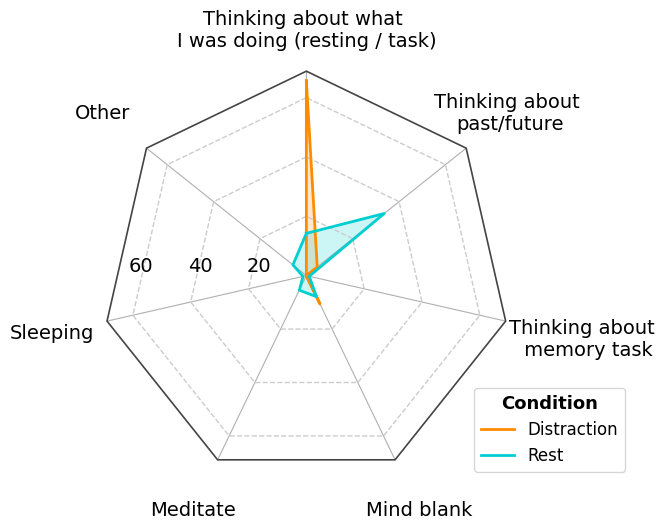

In [ ]:
value_cols = [
    'Thinking about what I was doing (resting / task)', 
    'Other',
    'Sleeping',
    'Meditate', 
    'Mind blank',
    'Thinking about memory task',
    'Thinking about past/future', 
]

# Possibility to chose between median or mean
median_df = df.groupby("condition")[value_cols].median()
# mean_df = df.groupby("condition")[value_cols].mean()

conditions = median_df.index.tolist()
N = len(value_cols)
theta = radar_factory(N, frame='polygon')

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='radar')

colors = {
    "Rest": 'darkturquoise',      
    "Distraction": 'darkorange', 
}

# Global max for consistent scale
global_max = np.nanmax(median_df.values)

grid_vals = np.linspace(0, 100, 6)[1:]
ax.set_rgrids(
    grid_vals,  
    angle=90,
    fontsize=14
)
ax.yaxis.grid(True, color="#cccccc", linewidth=1, linestyle='--')
ax.spines['polar'].set_color("#444444")
ax.spines['polar'].set_linewidth(1.2)

for condition in conditions:
    values = median_df.loc[condition].values
    values_safe = np.nan_to_num(values, nan=0.0)
    color = colors.get(condition, "#7F8C8D")
    ax.plot(theta, values_safe, color=color, linewidth=2, label=condition)
    ax.fill(theta, values_safe, facecolor=color, alpha=0.20)

# Axis labels
value_cols = [
    v.replace('_', ' ')
    .replace('Thinking about what I was doing (resting / task)', 'Thinking about what \nI was doing (resting / task)')
    .replace('Thinking about memory task', 'Thinking about \nmemory task')
    .replace('Thinking about past/future', 'Thinking about \npast/future')
    for v in value_cols
]
ax.set_varlabels(value_cols)
ax.tick_params(axis='x', pad=30)
ax.get_xticklabels()[0].set_visible(False)
ax.get_xticklabels()[4].set_visible(False) 

# Add the first label back with custom padding
ax.text(
    theta[0],
    ax.get_rmax() * 1.2,
    'Thinking about what \nI was doing (resting / task)',
    ha='center',
    va='center',
    fontsize=14,
)

ax.text(
    theta[5],
    ax.get_rmax() * 1.4,
    'Thinking about \n memory task',
    ha='center',
    va='center',
    fontsize=14,
)

for label in ax.get_xticklabels():
    label.set_fontsize(14)

# plt.title("Mental activities during post-learning conditions (%)", 
#           fontsize=16, weight='bold', x= 0.6,y=1.2)
legend = plt.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize = 12, title = 'Condition')
legend.get_title().set_fontsize(13)  
legend.get_title().set_fontweight('bold')
plt.tight_layout()
plt.show()


fig.savefig(os.path.join(figures_path, 'Figure_5B.png'), dpi=300, format='png', bbox_inches='tight')
fig.savefig(os.path.join(figures_path, 'Figure_5B.pdf'), format='pdf', bbox_inches='tight')

#### Figure 5C-D

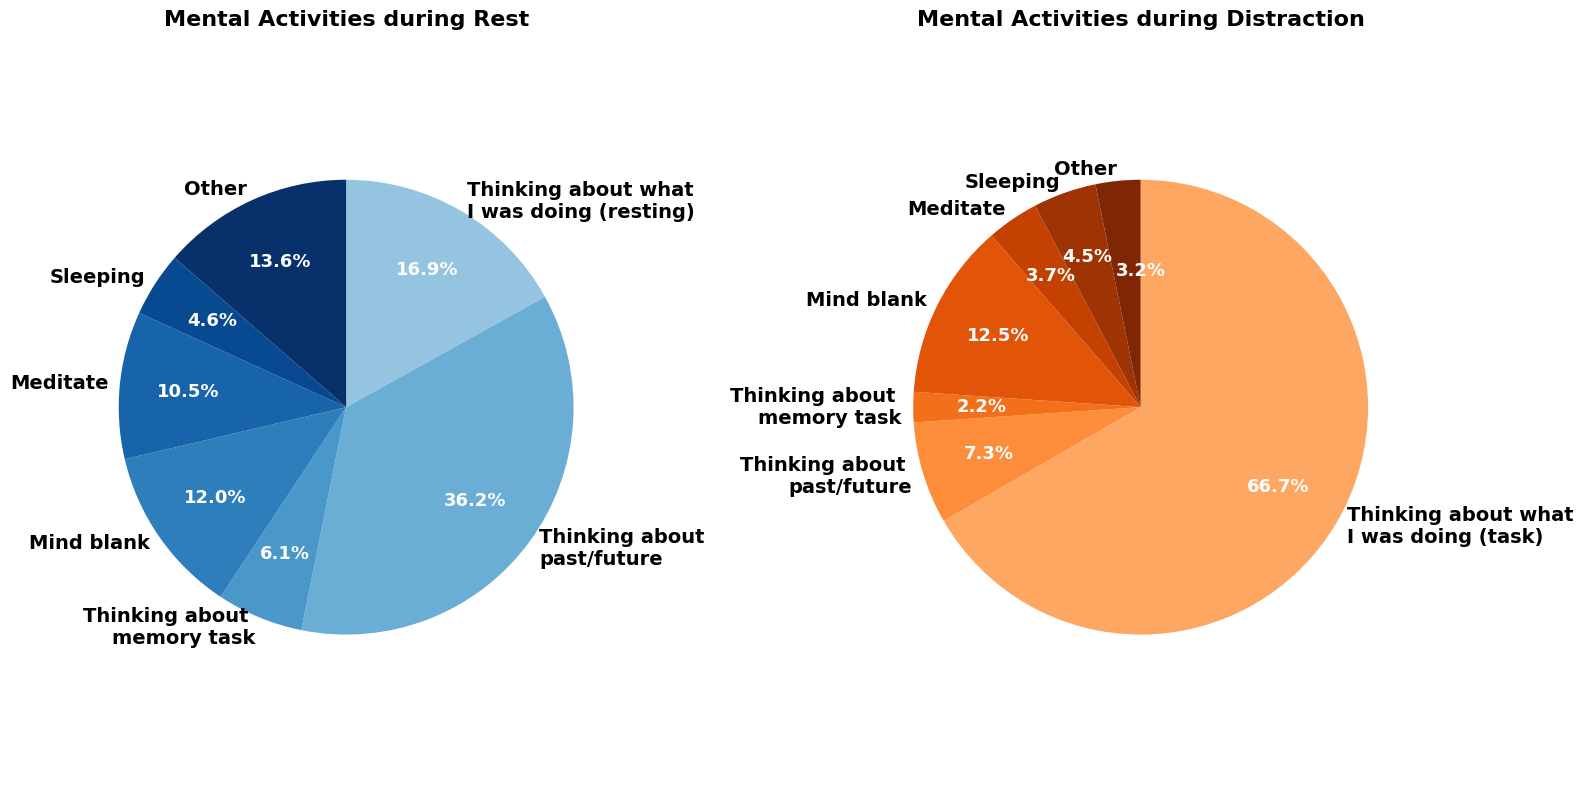

In [8]:
value_cols = [
    'Thinking about what I was doing (resting / task)',
    'Thinking about past/future',
    'Thinking about memory task',
    'Mind blank',
    'Meditate',
    'Sleeping',
    'Other',
]

mean_df = df.groupby("condition")[value_cols].mean()

condition_palettes = {
    "Rest": plt.cm.Blues(np.linspace(0.4, 1, len(value_cols))),
    "Distraction": plt.cm.Oranges(np.linspace(0.4, 1, len(value_cols))),
}

def my_autopct(pct):
    return f"{pct:.1f}%"

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plt.subplots_adjust(wspace=1)
conditions = ["Rest", "Distraction"]

for ax, condition in zip(axes, conditions):
    colors = condition_palettes.get(condition, plt.cm.tab20(np.linspace(0, 1, len(value_cols))))
    values = mean_df.loc[condition].values
    if condition == 'Rest':
        formatted_labels = [
            v.replace('_', ' ')
            .replace('Thinking about what I was doing (resting / task)', 'Thinking about what \nI was doing (resting)')
            .replace('Thinking about memory task', 'Thinking about \nmemory task')
            .replace('Thinking about past/future', 'Thinking about \npast/future')
            for v in value_cols
        ]
    else:
        formatted_labels = [
            v.replace('_', ' ')
            .replace('Thinking about what I was doing (resting / task)', 'Thinking about what \nI was doing (task)')
            .replace('Thinking about memory task', 'Thinking about \nmemory task')
            .replace('Thinking about past/future', 'Thinking about \npast/future')
            for v in value_cols
        ]

    wedges, texts, autotexts = ax.pie(
        values,
        labels=formatted_labels,
        autopct=my_autopct,
        pctdistance=0.7,
        labeldistance=1.05,
        startangle=90,
        counterclock=False,
        colors=colors,
        textprops={'fontsize': 14, 'fontweight': 'bold'},
    )

    for text in ax.texts:
        if '%' in text.get_text():
            text.set_fontsize(13)
            text.set_weight('bold')
            text.set_color('white')

    if condition == "Distraction":
        other_index = formatted_labels.index("Other")
        other_autotext = autotexts[other_index]
        # Set a new position (x, y) for the "Other" percentage text
        other_autotext.set_position((0, 0.6)) 

    ax.set_title(
        f"Mental Activities during {condition}",
        fontsize=16,
        weight='bold',
        y=1
    )

    ax.axis('equal')

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_path, 'Figure_5C-D.png'), dpi=300, format='png', bbox_inches='tight')
fig.savefig(os.path.join(figures_path, 'Figure_5C-D.pdf'), format='pdf', bbox_inches='tight')
